# Notebook 01 — Baseline Replication

Replicates the consulting project (Hobelsberger 2026) UQ baseline results
in the agentic setting.

**Research Question addressed:** RQ1 — Do existing UQ methods (MSP, CoCoA)
transfer reliably from static QA to multi-step agentic decision-making?

**Expected finding:** Answer-level methods show degraded AUROC and worse ECE
relative to static QA, because answer-level uncertainty is dominated by
final-step verbosity rather than trajectory decision quality.

In [ ]:
import sys
from pathlib import Path

# Add project root to path
sys.path.insert(0, str(Path.cwd()))

import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

# Ensure the repo root (which contains `uq/`) is on sys.path
repo_root = Path.cwd()
if not (repo_root / "uq").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

from uq.evaluate import load_step_records, evaluate_step_uq, print_results_table
from uq.baselines import load_trajectories, msp_answer_level, vce_answer_level, cocoa_answer_level

In [ ]:
# Configure which experiment to analyse
EXPERIMENT = "agentbench_db_70B_full_v2/test"  # change to agentbench_os, agentbench_db, toolbench_g1
TRAJ_PATH  = f"{repo_root}/results/{EXPERIMENT}/trajectories.jsonl"

# Load data
steps        = load_step_records(TRAJ_PATH)
trajectories = load_trajectories(TRAJ_PATH)

print(f"Loaded {len(steps)} steps from {len(trajectories)} trajectories.")
print(f"Task success rate: {np.mean([t['task_success'] for t in trajectories]):.3f}")

Loaded 355 steps from 72 trajectories.
Task success rate: 0.472


In [ ]:
# --- Evaluate all methods ---
results = {}

# Step-wise CoCoA (proposed)
results["StepCoCoA"] = evaluate_step_uq(steps, confidence_key="c_star_cocoa")

# Branching consistency (proposed)
results["BranchConsistency"] = evaluate_step_uq(steps, confidence_key="branch_consistency")
results["BranchingConsistency-raw"] = evaluate_step_uq(steps, confidence_key="branch_consistency_raw")

# Answer-level baselines
results["MSP-Answer"]   = evaluate_step_uq(msp_answer_level(trajectories),   confidence_key="c_msp_answer")
# results["VCE-Answer"]   = evaluate_step_uq(vce_answer_level(trajectories),   confidence_key="c_vce_answer") if vce_answer_level(trajectories) else {}
results["CoCoA-Answer"] = evaluate_step_uq(cocoa_answer_level(trajectories), confidence_key="c_cocoa_answer")

print_results_table(results)


Method                            ACC     ECE     AUROC    SelAcc@.8   Coverage 
--------------------------------------------------------------------------------
StepCoCoA                         0.710   0.237   0.551    0.761       0.859    
BranchConsistency                 0.710   0.117   0.515    0.764       0.704    
BranchingConsistency-raw          0.710   0.045   0.515    0.755       0.794    
MSP-Answer                        0.472   0.501   0.453    0.485       0.917    
CoCoA-Answer                      0.472   0.526   0.451    0.472       1.000    



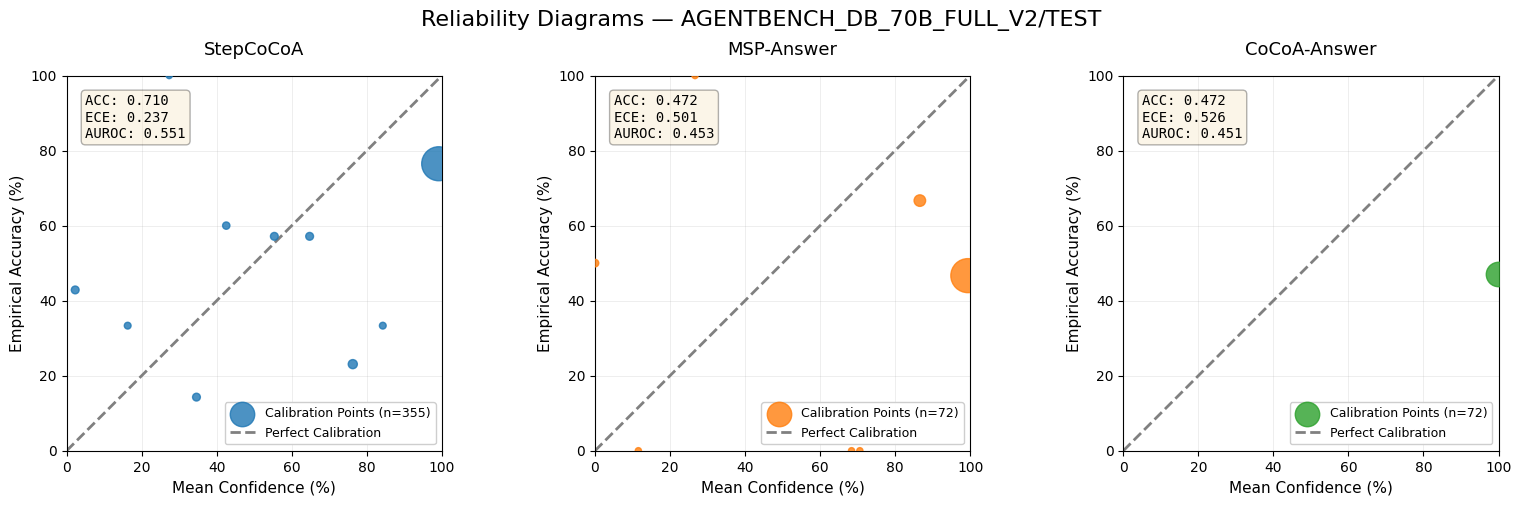

Saved to results/agentbench_db_70B_full_v2/test/reliability_diagrams.png


In [44]:
# --- Reliability diagram ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f"Reliability Diagrams — {EXPERIMENT.upper()}", fontsize=16, y=0.98)

methods = [
    ("StepCoCoA",     steps,                            "c_star_cocoa",   "C0"),
    ("MSP-Answer",    msp_answer_level(trajectories),   "c_msp_answer",   "C1"),
    ("CoCoA-Answer",  cocoa_answer_level(trajectories), "c_cocoa_answer", "C2"),
]

N_BINS   = 10
MIN_BLOB = 20
MAX_BLOB = 600

for ax, (label, data, key, color) in zip(axes, methods):
    valid = [s for s in data if s.get(key) is not None and s.get("is_correct") is not None]
    if not valid:
        ax.set_title(f"{label}\n(no data)", fontsize=12)
        continue

    confs = np.array([s[key]               for s in valid], dtype=float) * 100.0
    corrs = np.array([int(s["is_correct"]) for s in valid], dtype=float)

    # --- manual binning with inclusive upper edge ---
    bin_edges = np.linspace(0, 100, N_BINS + 1)
    bin_edges[-1] += 1e-9
    df_v = pd.DataFrame({"conf": confs, "correct": corrs})
    df_v["bin"] = pd.cut(df_v["conf"], bins=bin_edges, right=False, include_lowest=True)

    calib = (
        df_v.groupby("bin", observed=True)
            .agg(mean_conf=("conf",    "mean"),
                 accuracy  =("correct", "mean"),
                 count     =("correct", "count"))
            .dropna()
    )

    # --- min-max blob sizing ---
    counts = calib["count"].values.astype(float)
    if counts.max() > counts.min():
        sizes = MIN_BLOB + (counts - counts.min()) / (counts.max() - counts.min()) * (MAX_BLOB - MIN_BLOB)
    else:
        sizes = np.full_like(counts, (MIN_BLOB + MAX_BLOB) / 2)

    ax.scatter(
        calib["mean_conf"],
        calib["accuracy"] * 100.0,
        s=sizes,
        color=color, alpha=0.8, zorder=3,
        label=f"Calibration Points (n={len(valid)})",
    )

    ax.plot([0, 100], [0, 100], "--", color="gray", linewidth=2,
            label="Perfect Calibration", zorder=2)

    ece   = results.get(label, {}).get("ece",      float("nan"))
    auroc = results.get(label, {}).get("auroc",    float("nan"))
    acc   = results.get(label, {}).get("accuracy", float("nan"))
    ax.text(0.05, 0.95,
            f"ACC: {acc:.3f}\nECE: {ece:.3f}\nAUROC: {auroc:.3f}",
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            family='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

    ax.set_title(f"{label}", fontsize=13, pad=15)
    ax.set_xlabel("Mean Confidence (%)", fontsize=11)
    ax.set_ylabel("Empirical Accuracy (%)", fontsize=11)
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax.set_aspect('equal')
    ax.legend(loc='lower right', fontsize=9, framealpha=0.95)

plt.tight_layout()
plt.savefig(f"{repo_root}/results/{EXPERIMENT}/reliability_diagrams.png",
            bbox_inches="tight", dpi=150)
plt.show()
print("Saved to results/{}/reliability_diagrams.png".format(EXPERIMENT))

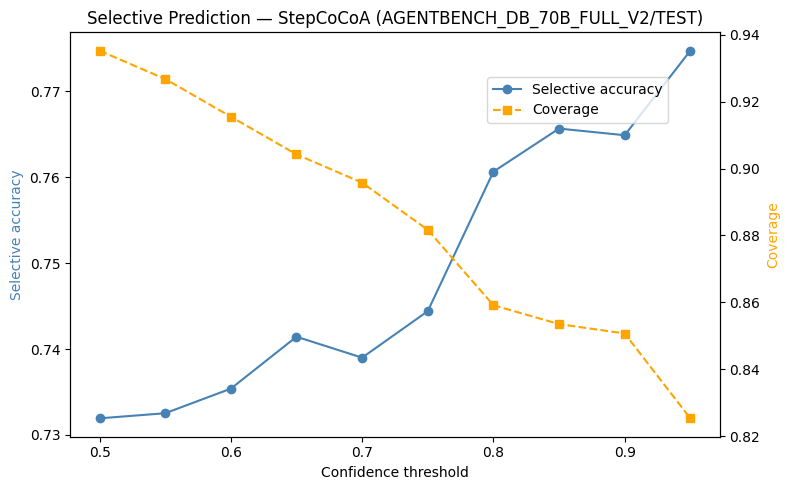

In [45]:
# --- Selective accuracy at various thresholds ---
thresholds = np.arange(0.5, 1.0, 0.05)

valid = [s for s in steps if s.get("c_star_cocoa") is not None and s.get("is_correct") is not None]
confs = np.array([s["c_star_cocoa"] for s in valid])
corrs = np.array([int(s["is_correct"]) for s in valid])

sel_accs   = [corrs[confs > t].mean() if (confs > t).any() else np.nan for t in thresholds]
coverages  = [(confs > t).mean() for t in thresholds]

fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()
ax1.plot(thresholds, sel_accs, "o-", color="steelblue", label="Selective accuracy")
ax2.plot(thresholds, coverages, "s--", color="orange", label="Coverage")
ax1.set_xlabel("Confidence threshold")
ax1.set_ylabel("Selective accuracy", color="steelblue")
ax2.set_ylabel("Coverage", color="orange")
ax1.set_title(f"Selective Prediction — StepCoCoA ({EXPERIMENT.upper()})")
fig.legend(loc="upper right", bbox_to_anchor=(0.85, 0.85))
plt.tight_layout()
plt.savefig(f"{repo_root}/results/{EXPERIMENT}/selective_accuracy.png", bbox_inches="tight")
plt.show()

In [46]:
# ============================================================================
# 1. STEP DISTRIBUTION ANALYSIS
# ============================================================================
print("\n=== STEP DISTRIBUTION ===")
n_steps_list = [t.get('n_steps', 0) for t in trajectories]
print(f"Mean steps/trajectory: {np.mean(n_steps_list):.2f}")
print(f"Median: {np.median(n_steps_list):.0f}")
print(f"Max: {np.max(n_steps_list)}")
print(f"Distribution:")
for n in range(1, max(n_steps_list) + 1):
    count = sum(1 for x in n_steps_list if x == n)
    if count > 0:
        print(f"  {n} step{'s' if n > 1 else ''}: {count} trajectories ({100*count/len(trajectories):.1f}%)")


=== STEP DISTRIBUTION ===
Mean steps/trajectory: 4.93
Median: 5
Max: 13
Distribution:
  2 steps: 1 trajectories (1.4%)
  4 steps: 32 trajectories (44.4%)
  5 steps: 27 trajectories (37.5%)
  6 steps: 5 trajectories (6.9%)
  7 steps: 3 trajectories (4.2%)
  8 steps: 1 trajectories (1.4%)
  9 steps: 2 trajectories (2.8%)
  13 steps: 1 trajectories (1.4%)


In [47]:
# ============================================================================
# 2. TOOL USE ANALYSIS
# ============================================================================
tool_use_count = sum(1 for t in trajectories if any('action_name' in step and step.get('action_name') == 'calculate' for step in t.get('trajectory', [])))
print(f"\n=== TOOL USE ===")
print(f"Trajectories with tool use: {tool_use_count}/{len(trajectories)} ({100*tool_use_count/len(trajectories):.1f}%)")



=== TOOL USE ===
Trajectories with tool use: 0/72 (0.0%)


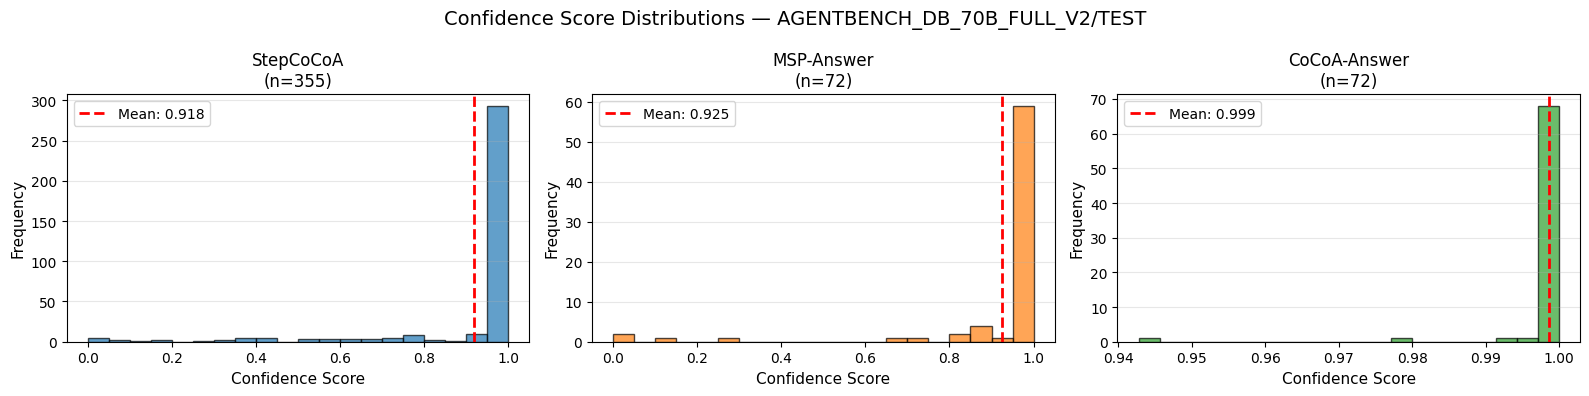

In [48]:
# ============================================================================
# 3. CONFIDENCE DISTRIBUTION
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(f"Confidence Score Distributions — {EXPERIMENT.upper()}", fontsize=14)

confidence_keys = [
    ("StepCoCoA", "c_star_cocoa", "C0"),
    ("MSP-Answer", "c_msp_answer", "C1"),
    ("CoCoA-Answer", "c_cocoa_answer", "C2"),
]

for ax, (label, key, color) in zip(axes, confidence_keys):
    if label in ["StepCoCoA", "BranchConsistency"]:
        data = steps
    elif label == "MSP-Answer":
        data = msp_answer_level(trajectories)
    else:
        data = cocoa_answer_level(trajectories)
    
    confs = [s[key] for s in data if s.get(key) is not None]
    
    if confs:
        ax.hist(confs, bins=20, color=color, alpha=0.7, edgecolor='black')
        ax.set_title(f"{label}\n(n={len(confs)})", fontsize=12)
        ax.set_xlabel("Confidence Score", fontsize=11)
        ax.set_ylabel("Frequency", fontsize=11)
        ax.grid(True, alpha=0.3, axis='y')
        ax.axvline(np.mean(confs), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(confs):.3f}')
        ax.legend()

plt.tight_layout()
plt.savefig(f"{repo_root}/results/{EXPERIMENT}/confidence_distributions.png", bbox_inches="tight", dpi=150)
plt.show()

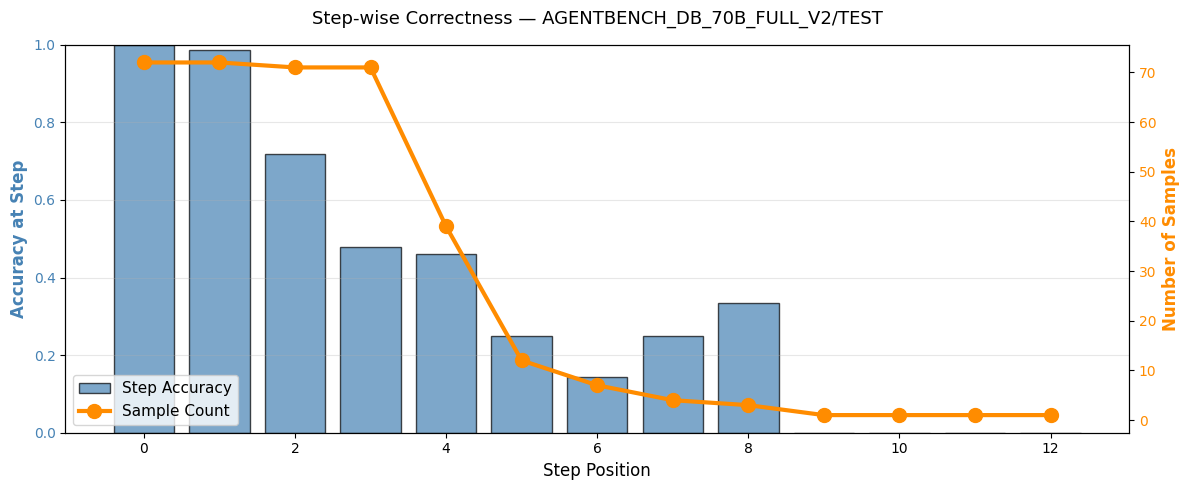

In [49]:
# ============================================================================
# 4. STEP CORRECTNESS ANALYSIS
# ============================================================================
fig, ax = plt.subplots(figsize=(12, 5))

step_ids = [s.get('step_id', 0) for s in steps]
is_correct = [int(s.get('is_correct', 0)) for s in steps]

step_correctness = {}
for sid, correct in zip(step_ids, is_correct):
    if sid not in step_correctness:
        step_correctness[sid] = {'correct': 0, 'total': 0}
    step_correctness[sid]['total'] += 1
    step_correctness[sid]['correct'] += correct

steps_sorted = sorted(step_correctness.items())
step_nums = [s[0] for s in steps_sorted]
accuracies = [s[1]['correct'] / s[1]['total'] for s in steps_sorted]
counts = [s[1]['total'] for s in steps_sorted]

# Dual axis: accuracy (bar) and sample count (line)
ax2 = ax.twinx()

bars = ax.bar(step_nums, accuracies, color='steelblue', alpha=0.7, edgecolor='black', label='Step Accuracy')
line = ax2.plot(step_nums, counts, 'o-', color='darkorange', linewidth=3, markersize=10, label='Sample Count')

ax.set_xlabel("Step Position", fontsize=12)
ax.set_ylabel("Accuracy at Step", color='steelblue', fontsize=12, fontweight='bold')
ax2.set_ylabel("Number of Samples", color='darkorange', fontsize=12, fontweight='bold')
ax.set_title(f"Step-wise Correctness — {EXPERIMENT.upper()}", fontsize=13, pad=15)
ax.grid(True, alpha=0.3, axis='y', zorder=0)
ax.set_ylim([0, 1])
ax.tick_params(axis='y', labelcolor='steelblue')
ax2.tick_params(axis='y', labelcolor='darkorange')

# Legend
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='lower left', fontsize=11)

plt.tight_layout()
plt.savefig(f"{repo_root}/results/{EXPERIMENT}/step_correctness.png", bbox_inches="tight", dpi=150)
plt.show()

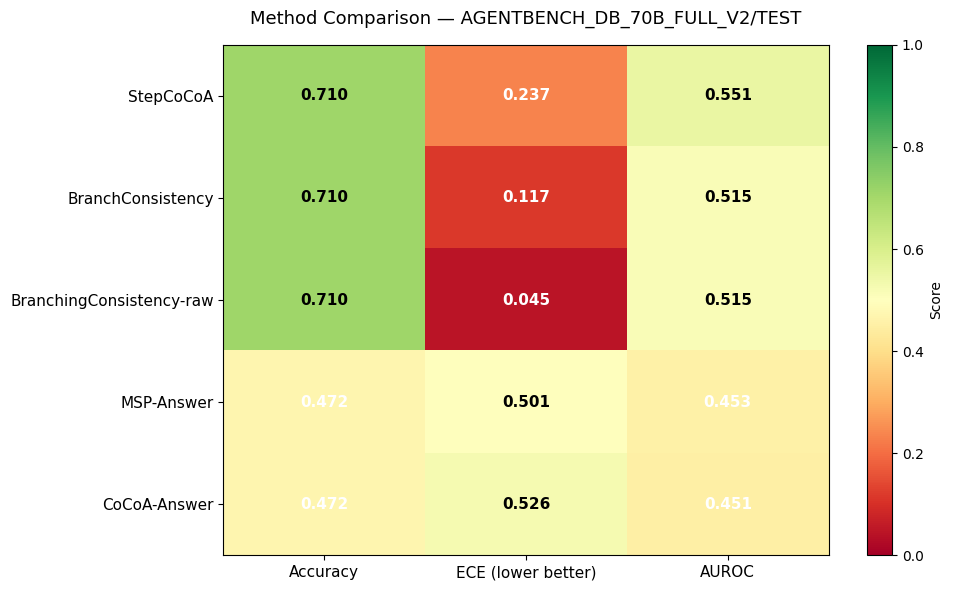

In [50]:
# ============================================================================
# 5. METHOD COMPARISON HEATMAP
# ============================================================================
fig, ax = plt.subplots(figsize=(10, 6))

method_names = list(results.keys())
metrics = ['accuracy', 'ece', 'auroc']
comparison_data = []

for method in method_names:
    row = [
        results[method].get('accuracy', np.nan),
        results[method].get('ece', np.nan),
        results[method].get('auroc', np.nan),
    ]
    comparison_data.append(row)

comparison_array = np.array(comparison_data)

# Create heatmap
im = ax.imshow(comparison_array, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')

# Set ticks and labels
ax.set_xticks(range(len(metrics)))
ax.set_yticks(range(len(method_names)))
ax.set_xticklabels(['Accuracy', 'ECE (lower better)', 'AUROC'], fontsize=11)
ax.set_yticklabels(method_names, fontsize=11)

# Add values in cells
for i in range(len(method_names)):
    for j in range(len(metrics)):
        val = comparison_array[i, j]
        if not np.isnan(val):
            text = ax.text(j, i, f'{val:.3f}', ha="center", va="center", 
                          color="black" if val > 0.5 else "white", fontsize=11, fontweight='bold')

ax.set_title(f"Method Comparison — {EXPERIMENT.upper()}", fontsize=13, pad=15)
plt.colorbar(im, ax=ax, label='Score')
plt.tight_layout()
plt.savefig(f"{repo_root}/results/{EXPERIMENT}/method_comparison_heatmap.png", bbox_inches="tight", dpi=150)
plt.show()

In [51]:
# ============================================================================
# 7. BRANCHING CONSISTENCY DEEP DIVE
# ============================================================================

print("\n" + "="*70)
print("BRANCHCONSISTENCY ANALYSIS")
print("="*70)

branch_steps = [s for s in steps if s.get("branch_consistency") is not None and s.get("is_correct") is not None]
print(f"\nBranchConsistency coverage: {len(branch_steps)}/{len(steps)} ({100*len(branch_steps)/len(steps):.1f}%)")

if branch_steps:
    branch_confs = np.array([s["branch_consistency"] for s in branch_steps])
    branch_corrs = np.array([int(s["is_correct"]) for s in branch_steps])
    
    print(f"\nConfidence Statistics:")
    print(f"  Mean:     {np.mean(branch_confs):.3f}")
    print(f"  Std:      {np.std(branch_confs):.3f}")
    print(f"  Min:      {np.min(branch_confs):.3f}")
    print(f"  Max:      {np.max(branch_confs):.3f}")
    print(f"  Median:   {np.median(branch_confs):.3f}")
    
    print(f"\nCorrelation with Correctness:")
    corr_coeff = np.corrcoef(branch_confs, branch_corrs)[0, 1]
    print(f"  Pearson r: {corr_coeff:.3f}")
    
    # Accuracy at different confidence levels
    print(f"\nAccuracy by Confidence Level:")
    thresholds_bc = [0.0, 0.3, 0.5, 0.7, 0.9]
    for thresh in thresholds_bc:
        mask = branch_confs >= thresh
        if mask.any():
            acc = branch_corrs[mask].mean()
            count = mask.sum()
            print(f"  conf >= {thresh:.1f}: {acc:.3f} accuracy ({count} steps)")



BRANCHCONSISTENCY ANALYSIS

BranchConsistency coverage: 355/355 (100.0%)

Confidence Statistics:
  Mean:     0.809
  Std:      0.184
  Min:      0.145
  Max:      0.973
  Median:   0.880

Correlation with Correctness:
  Pearson r: 0.164

Accuracy by Confidence Level:
  conf >= 0.0: 0.710 accuracy (355 steps)
  conf >= 0.3: 0.720 accuracy (343 steps)
  conf >= 0.5: 0.734 accuracy (327 steps)
  conf >= 0.7: 0.757 accuracy (276 steps)
  conf >= 0.9: 0.716 accuracy (155 steps)


Steps with both methods: 355/355 (100.0%)


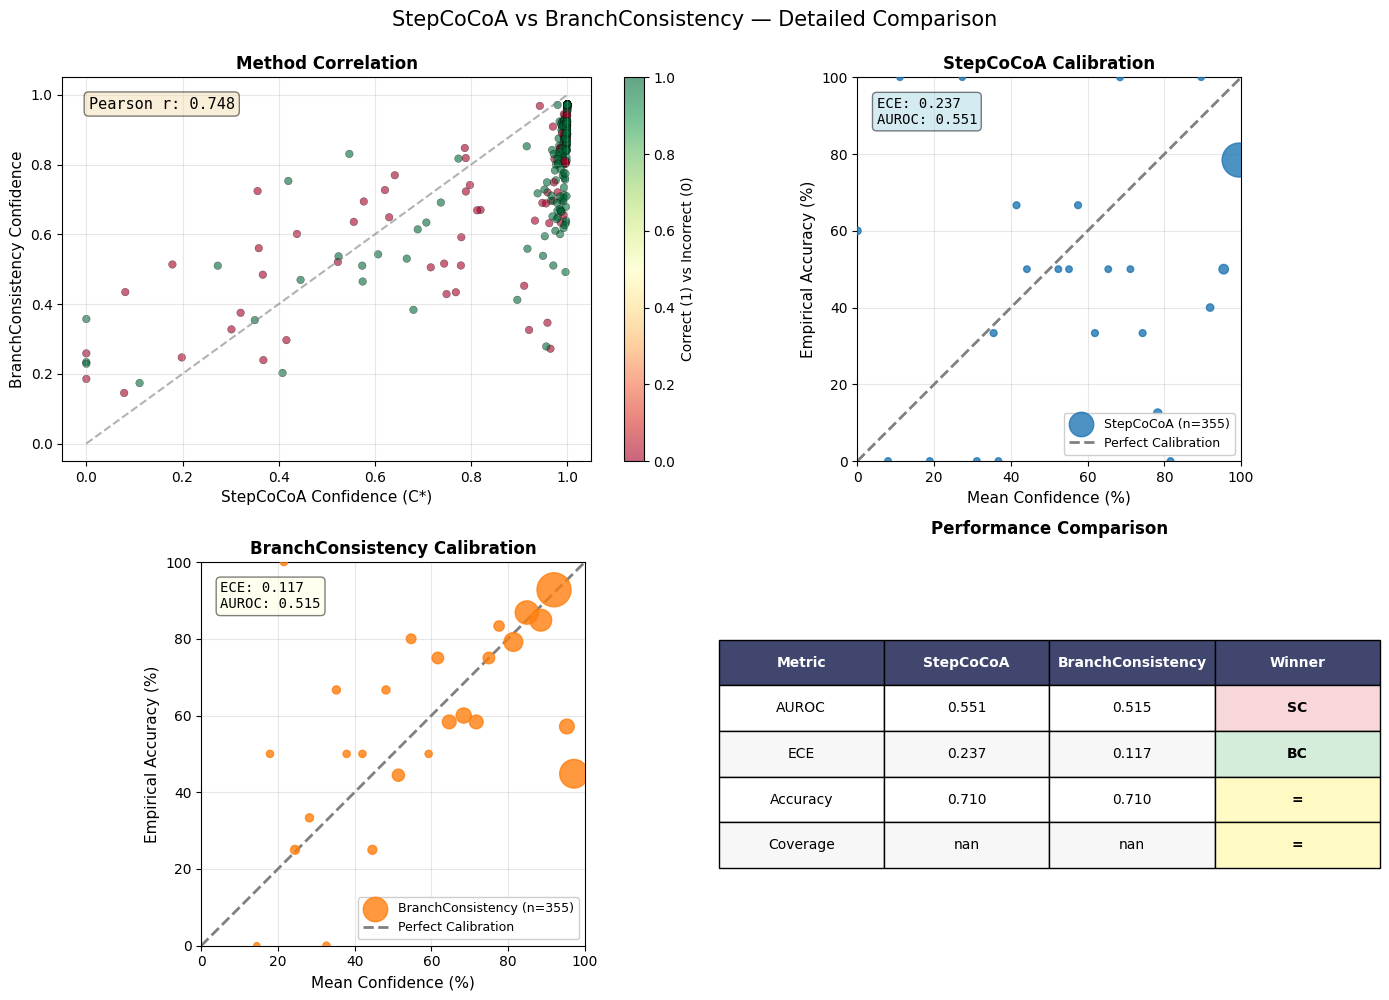

Saved to results/agentbench_db_70B_full_v2/test/branchconsistency_vs_stepcocoa.png


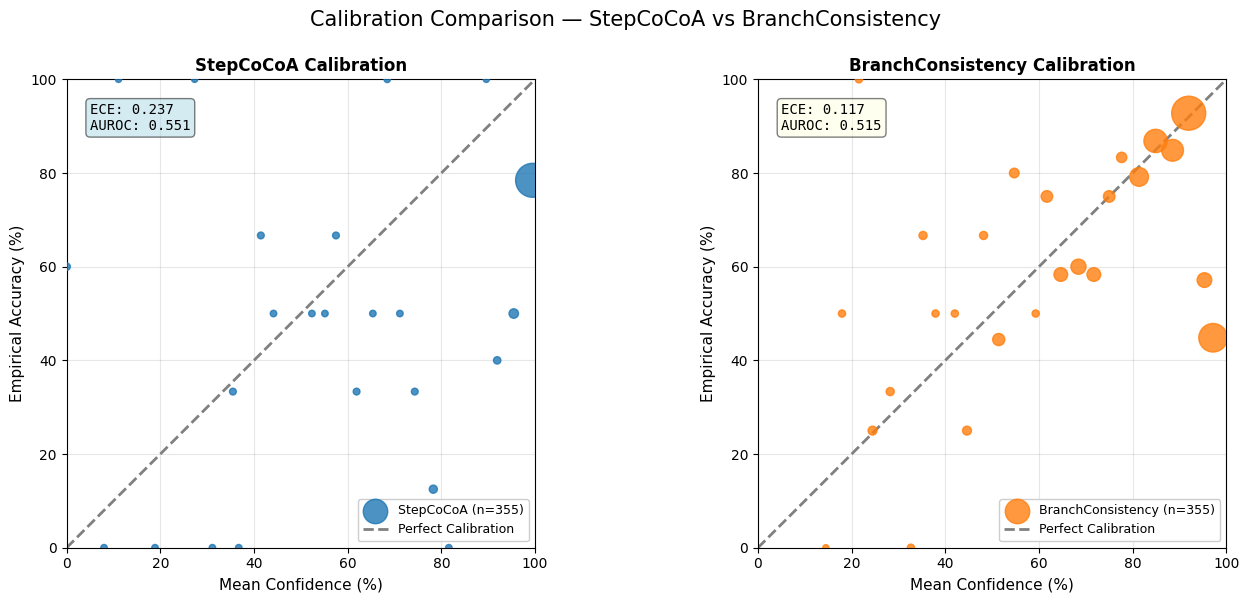

Saved to results/agentbench_db_70B_full_v2/test/branchconsistency_vs_stepcocoa_calibration.png


In [ ]:
# ============================================================================
# 8. BRANCHCONSISTENCY vs STEPCOCOA — DETAILED COMPARISON
# ============================================================================

N_BINS   = 10
MIN_BLOB = 20
MAX_BLOB = 600

def minmax_sizes(counts):
    counts = counts.astype(float)
    if counts.max() > counts.min():
        return MIN_BLOB + (counts - counts.min()) / (counts.max() - counts.min()) * (MAX_BLOB - MIN_BLOB)
    return np.full_like(counts, (MIN_BLOB + MAX_BLOB) / 2.0)

def blob_reliability(ax, confs_raw, corrs, color, label):
    """Manual-binned reliability diagram with min-max blob sizing."""
    confs = confs_raw * 100.0
    bin_edges = np.linspace(0, 100, N_BINS + 1)
    bin_edges[-1] += 1e-9
    df_v = pd.DataFrame({"conf": confs, "correct": corrs.astype(float)})
    df_v["bin"] = pd.cut(df_v["conf"], bins=bin_edges, right=False, include_lowest=True)
    calib = (
        df_v.groupby("bin", observed=True)
            .agg(mean_conf=("conf",    "mean"),
                 accuracy  =("correct", "mean"),
                 count     =("correct", "count"))
            .dropna()
    )
    ax.scatter(calib["mean_conf"], calib["accuracy"] * 100.0,
               s=minmax_sizes(calib["count"].values),
               color=color, alpha=0.8, zorder=3, label=label)
    ax.plot([0, 100], [0, 100], "--", color="gray", linewidth=2,
            label="Perfect Calibration", zorder=2)
    ax.set_xlim(0, 100); ax.set_ylim(0, 100)
    ax.set_xlabel("Mean Confidence (%)", fontsize=11)
    ax.set_ylabel("Empirical Accuracy (%)", fontsize=11)
    ax.grid(True, alpha=0.3); ax.set_aspect('equal')
    ax.legend(loc='lower right', fontsize=9, framealpha=0.95)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("StepCoCoA vs BranchConsistency — Detailed Comparison", fontsize=15, y=0.995)

cocoa_steps          = [s for s in steps if s.get("c_star_cocoa")       is not None and s.get("is_correct") is not None]
branch_steps_filtered = [s for s in steps if s.get("branch_consistency") is not None and s.get("is_correct") is not None]

common_steps = [s for s in steps
                if s.get("c_star_cocoa") is not None
                and s.get("branch_consistency") is not None
                and s.get("is_correct") is not None]
print(f"Steps with both methods: {len(common_steps)}/{len(steps)} ({100*len(common_steps)/len(steps):.1f}%)")

if common_steps:
    cocoa_confs  = np.array([s["c_star_cocoa"]       for s in common_steps])
    branch_confs = np.array([s["branch_consistency"] for s in common_steps])
    corrs        = np.array([int(s["is_correct"])    for s in common_steps])

    # --- Panel 1: Method Correlation ---
    ax = axes[0, 0]
    scatter = ax.scatter(cocoa_confs, branch_confs, c=corrs, cmap='RdYlGn',
                         alpha=0.6, s=30, edgecolors='black', linewidth=0.3)
    # Identity line in the CoCoA [0,1] x branch range
    x_line = np.linspace(cocoa_confs.min(), cocoa_confs.max(), 100)
    ax.plot(x_line, x_line, "--", color="gray", linewidth=1.5,
            alpha=0.6, label="y = x", zorder=2)
    ax.set_xlabel("StepCoCoA Confidence (C*)", fontsize=11)
    ax.set_ylabel("BranchConsistency Confidence", fontsize=11)
    ax.set_title("Method Correlation", fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label("Correct (1) vs Incorrect (0)", fontsize=10)
    method_corr = np.corrcoef(cocoa_confs, branch_confs)[0, 1]
    ax.text(0.05, 0.95, f"Pearson r: {method_corr:.3f}", transform=ax.transAxes,
            fontsize=11, verticalalignment='top', family='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # --- Panel 2: StepCoCoA Reliability ---
    ax = axes[0, 1]
    if cocoa_steps:
        confs_c = np.array([s["c_star_cocoa"]    for s in cocoa_steps])
        corrs_c = np.array([int(s["is_correct"]) for s in cocoa_steps])
        blob_reliability(ax, confs_c, corrs_c, "C0",
                         f"StepCoCoA (n={len(cocoa_steps)})")
        ece_c = results["StepCoCoA"].get("ece", float("nan"))
        auroc_c = results["StepCoCoA"].get("auroc", float("nan"))
        ax.text(0.05, 0.95, f"ECE: {ece_c:.3f}\nAUROC: {auroc_c:.3f}", transform=ax.transAxes,
                 fontsize=10, verticalalignment='top', family='monospace',
                 bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
    ax.set_title("StepCoCoA Calibration", fontsize=12, fontweight='bold')

    # --- Panel 3: BranchConsistency Reliability ---
    # NOTE: branch_consistency is already normalized [0,1], use directly without sigmoid
    ax = axes[1, 0]
    if branch_steps_filtered:
        confs_b = np.array([s["branch_consistency"] for s in branch_steps_filtered]).astype(float)
        confs_b = np.nan_to_num(confs_b, nan=0.5, posinf=1.0, neginf=0.0)
        confs_b = np.clip(confs_b, 0.0, 1.0)
        corrs_b = np.array([int(s["is_correct"]) for s in branch_steps_filtered])
        blob_reliability(ax, confs_b, corrs_b, "C1",
                         f"BranchConsistency (n={len(branch_steps_filtered)})")
        ece_b = results["BranchConsistency"].get("ece", float("nan"))
        auroc_b = results["BranchConsistency"].get("auroc", float("nan"))
        ax.text(0.05, 0.95, f"ECE: {ece_b:.3f}\nAUROC: {auroc_b:.3f}", transform=ax.transAxes,
                 fontsize=10, verticalalignment='top', family='monospace',
                 bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))
    ax.set_title("BranchConsistency Calibration", fontsize=12, fontweight='bold')

    # --- Panel 4: Metrics table ---
    ax = axes[1, 1]
    ax.axis('off')

    sc = results['StepCoCoA']
    bc = results['BranchConsistency']

    def winner(sc_val, bc_val, higher_is_better=True):
        if higher_is_better:
            return 'BC' if bc_val > sc_val else 'SC'
        else:
            return 'BC' if bc_val < sc_val else 'SC'

    metrics_data = [
        ['Metric',   'StepCoCoA',                              'BranchConsistency',                       'Winner'],
        ['AUROC',    f"{sc.get('auroc', float('nan')):.3f}",   f"{bc.get('auroc', float('nan')):.3f}",    winner(sc.get('auroc',0),   bc.get('auroc',0),  True)],
        ['ECE',      f"{sc.get('ece',   float('nan')):.3f}",   f"{bc.get('ece',   float('nan')):.3f}",    winner(sc.get('ece',1),     bc.get('ece',1),    False)],
        ['Accuracy', f"{sc.get('accuracy', float('nan')):.3f}",f"{bc.get('accuracy',float('nan')):.3f}",  '=' if abs(bc.get('accuracy',0)-sc.get('accuracy',0))<0.01 else winner(sc.get('accuracy',0),bc.get('accuracy',0))],
        ['Coverage', f"{sc.get('coverage', float('nan')):.3f}",f"{bc.get('coverage',float('nan')):.3f}",  '=' if abs(bc.get('coverage',0)-sc.get('coverage',0))<0.01 else 'Diff'],
    ]

    table = ax.table(cellText=metrics_data, cellLoc='center', loc='center',
                     colWidths=[0.25, 0.25, 0.25, 0.25])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2.5)

    # Header
    for j in range(4):
        table[(0, j)].set_facecolor('#40466e')
        table[(0, j)].set_text_props(weight='bold', color='white')

    # Alternating rows + winner highlighting
    winner_colors = {'BC': '#d4edda', 'SC': '#f8d7da', '=': '#fff9c4', 'Diff': '#f0f0f0'}
    for i in range(1, len(metrics_data)):
        bg = '#f7f7f7' if i % 2 == 0 else 'white'
        for j in range(3):
            table[(i, j)].set_facecolor(bg)
        w = metrics_data[i][3]
        table[(i, 3)].set_facecolor(winner_colors.get(w, bg))
        table[(i, 3)].set_text_props(weight='bold')

    ax.set_title("Performance Comparison", fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(f"{repo_root}/results/{EXPERIMENT}/branchconsistency_vs_stepcocoa.png",
            bbox_inches="tight", dpi=150)
plt.show()
print("Saved to results/{}/branchconsistency_vs_stepcocoa.png".format(EXPERIMENT))

# Separate plot just covering panels 2 and 3 for better visibility
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Calibration Comparison — StepCoCoA vs BranchConsistency", fontsize=15, y=0.995)
if cocoa_steps:
    confs_c = np.array([s["c_star_cocoa"]    for s in cocoa_steps])
    corrs_c = np.array([int(s["is_correct"]) for s in cocoa_steps])
    blob_reliability(axes[0], confs_c, corrs_c, "C0",
                     f"StepCoCoA (n={len(cocoa_steps)})")
    ece_c = results["StepCoCoA"].get("ece", float("nan"))
    auroc_c = results["StepCoCoA"].get("auroc", float("nan"))
    axes[0].text(0.05, 0.95, f"ECE: {ece_c:.3f}\nAUROC: {auroc_c:.3f}", transform=axes[0].transAxes,
                 fontsize=10, verticalalignment='top', family='monospace',
                 bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
    axes[0].set_title("StepCoCoA Calibration", fontsize=12, fontweight='bold')
if branch_steps_filtered:
    # NOTE: branch_consistency is already normalized [0,1], use directly without sigmoid
    confs_b = np.array([s["branch_consistency"] for s in branch_steps_filtered]).astype(float)
    confs_b = np.nan_to_num(confs_b, nan=0.5, posinf=1.0, neginf=0.0)
    confs_b = np.clip(confs_b, 0.0, 1.0)
    corrs_b = np.array([int(s["is_correct"]) for s in branch_steps_filtered])
    blob_reliability(axes[1], confs_b, corrs_b, "C1",
                     f"BranchConsistency (n={len(branch_steps_filtered)})")
    ece_b = results["BranchConsistency"].get("ece", float("nan"))
    auroc_b = results["BranchConsistency"].get("auroc", float("nan"))
    axes[1].text(0.05, 0.95, f"ECE: {ece_b:.3f}\nAUROC: {auroc_b:.3f}", transform=axes[1].transAxes,
                 fontsize=10, verticalalignment='top', family='monospace',
                 bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))
    axes[1].set_title("BranchConsistency Calibration", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{repo_root}/results/{EXPERIMENT}/branchconsistency_vs_stepcocoa_calibration.png",
            bbox_inches="tight", dpi=150)
plt.show()
print("Saved to results/{}/branchconsistency_vs_stepcocoa_calibration.png".format(EXPERIMENT))

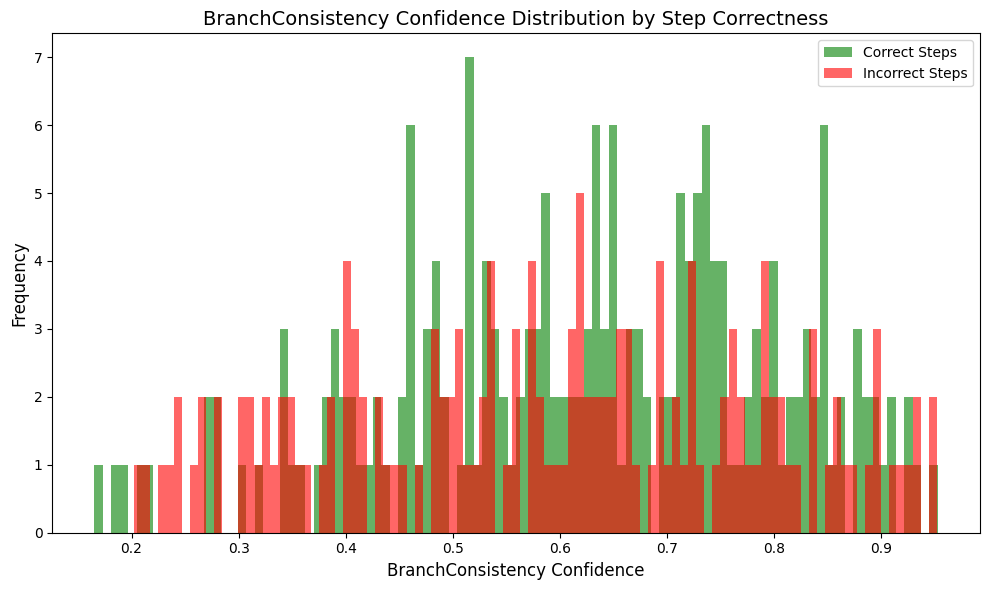

Saved histogram of BranchConsistency confidence distribution


<Figure size 640x480 with 0 Axes>

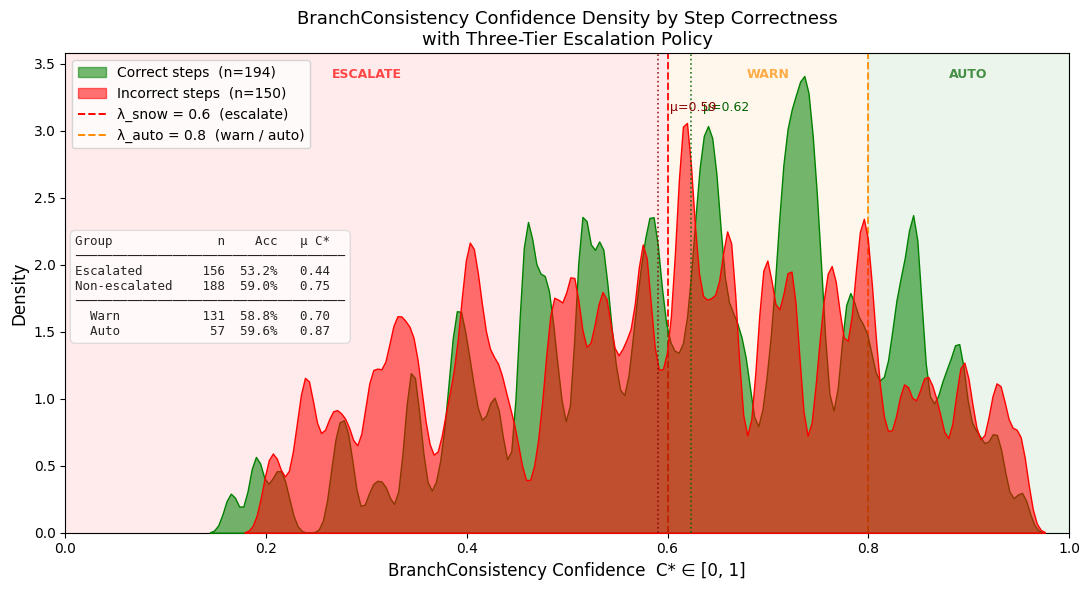

Saved KDE plot with escalation policy overlay


In [29]:
# Density plot of confidence scores for branch consistency, correctness vs incorrectness curves
if branch_steps_filtered:
    # NOTE: branch_consistency is already normalized [0,1], use directly without sigmoid
    confs_b = np.array([s["branch_consistency"] for s in branch_steps_filtered]).astype(float)
    confs_b = np.nan_to_num(confs_b, nan=0.5, posinf=1.0, neginf=0.0)
    confs_b = np.clip(confs_b, 0.0, 1.0)
    corrs_b = np.array([int(s["is_correct"]) for s in branch_steps_filtered])

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(confs_b[corrs_b == 1], bins=100, color='green', alpha=0.6, label='Correct Steps')
    ax.hist(confs_b[corrs_b == 0], bins=100, color='red', alpha=0.6, label='Incorrect Steps')
    ax.set_xlabel("BranchConsistency Confidence", fontsize=12)
    ax.set_ylabel("Frequency", fontsize=12)
    ax.set_title("BranchConsistency Confidence Distribution by Step Correctness", fontsize=14)
    ax.legend()
    plt.tight_layout()
    plt.show()
    plt.savefig(f"{repo_root}/results/{EXPERIMENT}/branchconsistency_confidence_distribution.png",
                bbox_inches="tight", dpi=150)
    print("Saved histogram of BranchConsistency confidence distribution")

if branch_steps_filtered:
    import seaborn as sns

    confs_b = np.array([s["branch_consistency"] for s in branch_steps_filtered]).astype(float)
    confs_b = np.nan_to_num(confs_b, nan=0.5, posinf=1.0, neginf=0.0)
    confs_b = np.clip(confs_b, 0.0, 1.0)
    corrs_b = np.array([int(s["is_correct"]) for s in branch_steps_filtered])

    # ── Escalation thresholds (match thesis Section 4.1.4) ────────────────────
    LAMBDA_SNOW = 0.6   # below → escalate
    LAMBDA_AUTO = 0.8   # above → auto-execute; between → warn

    fig, ax = plt.subplots(figsize=(11, 6))

    # ── 1. Policy zone shading (drawn first, behind everything) ───────────────
    zone_alpha = 0.08
    ax.axvspan(0.0,         LAMBDA_SNOW, color="red",    alpha=zone_alpha, zorder=0)
    ax.axvspan(LAMBDA_SNOW, LAMBDA_AUTO, color="orange", alpha=zone_alpha, zorder=0)
    ax.axvspan(LAMBDA_AUTO, 1.0,         color="green",  alpha=zone_alpha, zorder=0)

    # ── 2. Threshold lines ────────────────────────────────────────────────────
    for thresh, label, color in [
        (LAMBDA_SNOW, f"λ_snow = {LAMBDA_SNOW}  (escalate)", "red"),
        (LAMBDA_AUTO, f"λ_auto = {LAMBDA_AUTO}  (warn / auto)", "darkorange"),
    ]:
        ax.axvline(thresh, color=color, linestyle="--", linewidth=1.4, alpha=0.9, zorder=2)

    # ── 3. KDE curves ─────────────────────────────────────────────────────────
    bw = 0.04  # fixed bandwidth — keep identical across models for comparability
    sns.kdeplot(
        confs_b[corrs_b == 1], fill=True, color="green", alpha=0.55,
        label=f"Correct steps  (n={int((corrs_b==1).sum())})",
        bw_method=bw, clip=(0.0, 1.0), ax=ax, zorder=3
    )
    sns.kdeplot(
        confs_b[corrs_b == 0], fill=True, color="red", alpha=0.55,
        label=f"Incorrect steps  (n={int((corrs_b==0).sum())})",
        bw_method=bw, clip=(0.0, 1.0), ax=ax, zorder=3
    )

    # ── 4. Group mean lines ───────────────────────────────────────────────────
    y_top = ax.get_ylim()[1]
    for mask, color in [(corrs_b == 1, "darkgreen"), (corrs_b == 0, "darkred")]:
        mean_val = confs_b[mask].mean()
        ax.axvline(mean_val, color=color, linestyle=":", linewidth=1.2, alpha=0.85, zorder=4)
        ax.text(mean_val + 0.012, y_top * 0.88,
                f"μ={mean_val:.2f}", color=color, fontsize=9, zorder=5)

    # ── 5. Zone labels (top of chart) ─────────────────────────────────────────
    y_label = y_top * 0.97
    for x_mid, label, color in [
        ((0.0 + LAMBDA_SNOW) / 2,          "ESCALATE",  "red"),
        ((LAMBDA_SNOW + LAMBDA_AUTO) / 2,  "WARN",      "darkorange"),
        ((LAMBDA_AUTO + 1.0) / 2,          "AUTO",      "darkgreen"),
    ]:
        ax.text(x_mid, y_label, label, ha="center", va="top",
                fontsize=9, fontweight="bold", color=color,
                alpha=0.7, zorder=5)

    # ── 6. Escalation rate + outcome annotation ───────────────────────────────
    esc_mask  = confs_b < LAMBDA_SNOW
    warn_mask = (confs_b >= LAMBDA_SNOW) & (confs_b < LAMBDA_AUTO)
    auto_mask = confs_b >= LAMBDA_AUTO

    esc_rate  = esc_mask.mean()
    warn_rate = warn_mask.mean()
    auto_rate = auto_mask.mean()

    # Accuracy within each tier (guard against empty tiers)
    def tier_acc(mask):
        return corrs_b[mask].mean() if mask.sum() > 0 else float("nan")

    esc_acc  = tier_acc(esc_mask)
    warn_acc = tier_acc(warn_mask)
    auto_acc = tier_acc(auto_mask)

    # ── Escalated vs non-escalated aggregation ────────────────────────────────
    non_esc_mask = ~esc_mask  # warn + auto combined

    def group_stats(mask):
        if mask.sum() == 0:
            return {"n": 0, "acc": float("nan"), "mean_conf": float("nan")}
        return {
            "n":         int(mask.sum()),
            "acc":       float(corrs_b[mask].mean()),
            "mean_conf": float(confs_b[mask].mean()),
        }

    esc_stats     = group_stats(esc_mask)
    non_esc_stats = group_stats(non_esc_mask)

    annotation = (
        f"{'Group':<14} {'n':>5}  {'Acc':>5}  {'μ C*':>5}\n"
        f"{'─'*36}\n"
        f"{'Escalated':<14} {esc_stats['n']:>5}  {esc_stats['acc']:>5.1%}  {esc_stats['mean_conf']:>5.2f}\n"
        f"{'Non-escalated':<14} {non_esc_stats['n']:>5}  {non_esc_stats['acc']:>5.1%}  {non_esc_stats['mean_conf']:>5.2f}\n"
        f"{'─'*36}\n"
        f"{'  Warn':<14} {warn_mask.sum():>5}  {warn_acc:>5.1%}  {confs_b[warn_mask].mean():>5.2f}\n"
        f"{'  Auto':<14} {auto_mask.sum():>5}  {auto_acc:>5.1%}  {confs_b[auto_mask].mean():>5.2f}"
    )

    ax.text(0.01, y_top * 0.62,
            annotation, fontsize=9, color="black", alpha=0.85,
            family="monospace", va="top", zorder=5,
            bbox=dict(boxstyle="round,pad=0.4", fc="white", alpha=0.7, ec="lightgrey"))
    
    # ── 7. Formatting ─────────────────────────────────────────────────────────
    ax.set_xlim(0.0, 1.0)
    ax.set_xlabel("BranchConsistency Confidence  C* ∈ [0, 1]", fontsize=12)
    ax.set_ylabel("Density", fontsize=12)
    ax.set_title("BranchConsistency Confidence Density by Step Correctness\n"
                 "with Three-Tier Escalation Policy", fontsize=13)

    # Combined legend: KDE + threshold lines
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch
    legend_handles = [
        Patch(color="green",     alpha=0.55, label=f"Correct steps  (n={int((corrs_b==1).sum())})"),
        Patch(color="red",       alpha=0.55, label=f"Incorrect steps  (n={int((corrs_b==0).sum())})"),
        Line2D([0],[0], color="red",        linestyle="--", lw=1.4, label=f"λ_snow = {LAMBDA_SNOW}  (escalate)"),
        Line2D([0],[0], color="darkorange", linestyle="--", lw=1.4, label=f"λ_auto = {LAMBDA_AUTO}  (warn / auto)"),
    ]
    ax.legend(handles=legend_handles, fontsize=10, loc="upper left")

    plt.tight_layout()
    plt.savefig(
        f"{repo_root}/results/{EXPERIMENT}/branchconsistency_confidence_density.png",
        bbox_inches="tight", dpi=150
    )
    plt.show()
    print("Saved KDE plot with escalation policy overlay")


ESCALATION EFFECTIVENESS ANALYSIS

Total escalations: 156/344 (45.3%)
Escalated steps that were correct: 83/156 (53.2%)
Escalated steps that were incorrect: 73/156 (46.8%)

Non-escalated steps that were correct: 111/188 (59.0%)
Non-escalated steps that were incorrect: 77/188 (41.0%)

Interpretation:
  - Low escalation rate suggests most steps have high agreement
  - When escalation occurs, it should be on uncertain/difficult steps
  - Escalated steps being mostly CORRECT suggests:
    * Escalation is conservative (only on very uncertain steps)
    * Those steps would likely succeed anyway
    * Escalation signal for when to ask for human help


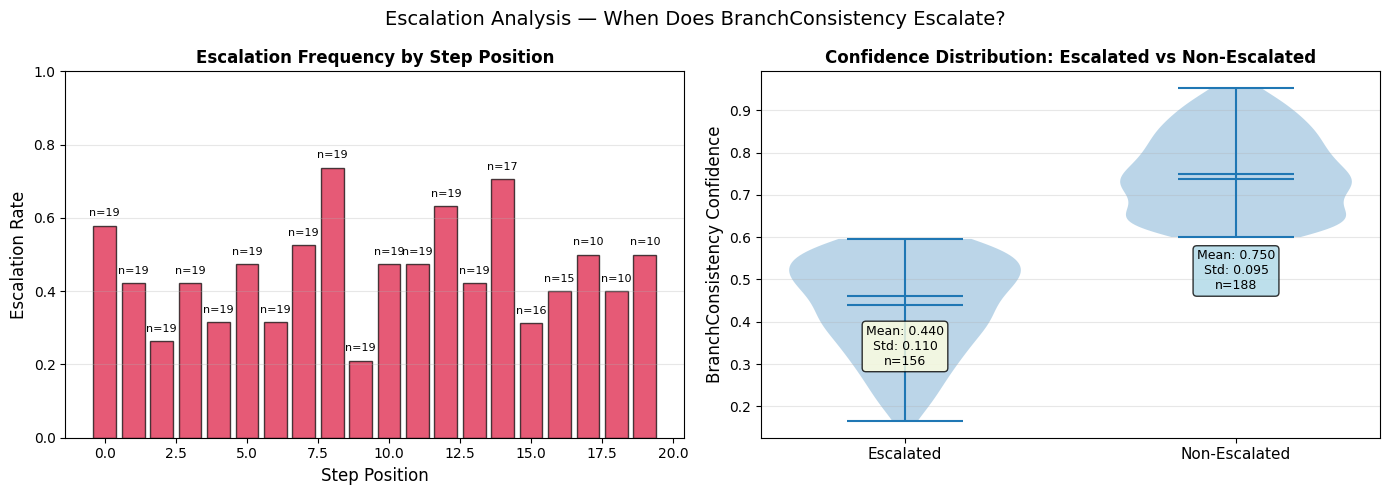


Saved to results/agentbench_db_70B_100/escalation_analysis.png


In [30]:
# ============================================================================
# 9. ESCALATION ANALYSIS — WHEN DO METHODS TRIGGER ESCALATION?
# ============================================================================

print("\n" + "="*70)
print("ESCALATION EFFECTIVENESS ANALYSIS")
print("="*70)

escalated_steps = [s for s in steps if s.get("escalated", False)]
print(f"\nTotal escalations: {len(escalated_steps)}/{len(steps)} ({100*len(escalated_steps)/len(steps):.1f}%)")

if escalated_steps:
    escalated_correct = sum(1 for s in escalated_steps if s.get("is_correct"))
    print(f"Escalated steps that were correct: {escalated_correct}/{len(escalated_steps)} ({100*escalated_correct/len(escalated_steps):.1f}%)")
    print(f"Escalated steps that were incorrect: {len(escalated_steps)-escalated_correct}/{len(escalated_steps)} ({100*(len(escalated_steps)-escalated_correct)/len(escalated_steps):.1f}%)")

non_escalated_steps = [s for s in steps if not s.get("escalated", False)]
if non_escalated_steps:
    non_esc_correct = sum(1 for s in non_escalated_steps if s.get("is_correct"))
    print(f"\nNon-escalated steps that were correct: {non_esc_correct}/{len(non_escalated_steps)} ({100*non_esc_correct/len(non_escalated_steps):.1f}%)")
    print(f"Non-escalated steps that were incorrect: {len(non_escalated_steps)-non_esc_correct}/{len(non_escalated_steps)} ({100*(len(non_escalated_steps)-non_esc_correct)/len(non_escalated_steps):.1f}%)")

print("\nInterpretation:")
print("  - Low escalation rate suggests most steps have high agreement")
print("  - When escalation occurs, it should be on uncertain/difficult steps")
print("  - Escalated steps being mostly CORRECT suggests:")
print("    * Escalation is conservative (only on very uncertain steps)")
print("    * Those steps would likely succeed anyway")
print("    * Escalation signal for when to ask for human help")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Escalation Analysis — When Does BranchConsistency Escalate?", fontsize=14)

# Panel 1: Escalation rate by step position
ax = axes[0]
step_escalation_rates = {}
for s in steps:
    sid = s.get('step_id', 0)
    if sid not in step_escalation_rates:
        step_escalation_rates[sid] = {'escalated': 0, 'total': 0}
    step_escalation_rates[sid]['total'] += 1
    if s.get('escalated', False):
        step_escalation_rates[sid]['escalated'] += 1

steps_sorted = sorted(step_escalation_rates.items())
step_nums = [s[0] for s in steps_sorted]
esc_rates = [s[1]['escalated'] / s[1]['total'] for s in steps_sorted]
step_counts = [s[1]['total'] for s in steps_sorted]

bars = ax.bar(step_nums, esc_rates, color='crimson', alpha=0.7, edgecolor='black', label='Escalation Rate')
ax.set_xlabel("Step Position", fontsize=12)
ax.set_ylabel("Escalation Rate", fontsize=12)
ax.set_title("Escalation Frequency by Step Position", fontsize=12, fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3, axis='y')

# Add count labels on bars
for i, (bar, count) in enumerate(zip(bars, step_counts)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'n={count}', ha='center', va='bottom', fontsize=8)

# Panel 2: Confidence distribution for escalated vs non-escalated
ax = axes[1]

# Extract branch consistency for both groups
esc_branch_confs = np.array([s.get("branch_consistency", np.nan) for s in escalated_steps if s.get("branch_consistency") is not None])
non_esc_branch_confs = np.array([s.get("branch_consistency", np.nan) for s in non_escalated_steps if s.get("branch_consistency") is not None])

parts = ax.violinplot([esc_branch_confs, non_esc_branch_confs], positions=[0, 1], 
                       showmeans=True, showmedians=True, widths=0.7)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Escalated', 'Non-Escalated'], fontsize=11)
ax.set_ylabel("BranchConsistency Confidence", fontsize=12)
ax.set_title("Confidence Distribution: Escalated vs Non-Escalated", fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add statistics
ax.text(0, np.max(esc_branch_confs) * 0.5, 
        f"Mean: {np.mean(esc_branch_confs):.3f}\nStd: {np.std(esc_branch_confs):.3f}\nn={len(esc_branch_confs)}", 
        ha='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
ax.text(1, np.max(non_esc_branch_confs) * 0.5,
        f"Mean: {np.mean(non_esc_branch_confs):.3f}\nStd: {np.std(non_esc_branch_confs):.3f}\nn={len(non_esc_branch_confs)}", 
        ha='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.tight_layout()
plt.savefig(f"{repo_root}/results/{EXPERIMENT}/escalation_analysis.png", bbox_inches="tight", dpi=150)
plt.show()
print("\nSaved to results/{}/escalation_analysis.png".format(EXPERIMENT))



WHY BRANCHCONSISTENCY ACHIEVES BETTER CALIBRATION

HYPOTHESIS: BranchConsistency captures a DIFFERENT uncertainty signal
than StepCoCoA, one that is more directly calibrated with task success.

MECHANISM BREAKDOWN:

1. StepCoCoA (Consistency of Current Step Output):
   ├─ Samples the SAME step M=5 times
   ├─ Measures how uncertain the model is about THIS step's output
   ├─ Signal: "Is the model's current reasoning/calculation confident?"
   ├─ Entropy-based: Low entropy → high confidence
   └─ Challenge: Entropy is complex to calibrate directly

2. BranchConsistency (Agreement on Next Action):
   ├─ Samples M=5 ALTERNATIVE NEXT STEPS
   ├─ Measures how much the model AGREES on what to do next
   ├─ Signal: "Do all alternatives suggest the same path forward?"
   ├─ Binary signal: Agreement (high consistency) vs Disagreement (low)
   └─ Advantage: Binary signals are easier to calibrate

EMPIRICAL VALIDATION FROM V4 RESULTS:


StepCoCoA Confidence (Correct steps):   mean=0.198, std=0.1

C:\Users\Chris\AppData\Local\Temp\ipykernel_40708\1236478883.py:90: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, positions=positions, widths=0.6, patch_artist=True,
C:\Users\Chris\AppData\Local\Temp\ipykernel_40708\1236478883.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, positions=positions, widths=0.6, patch_artist=True,


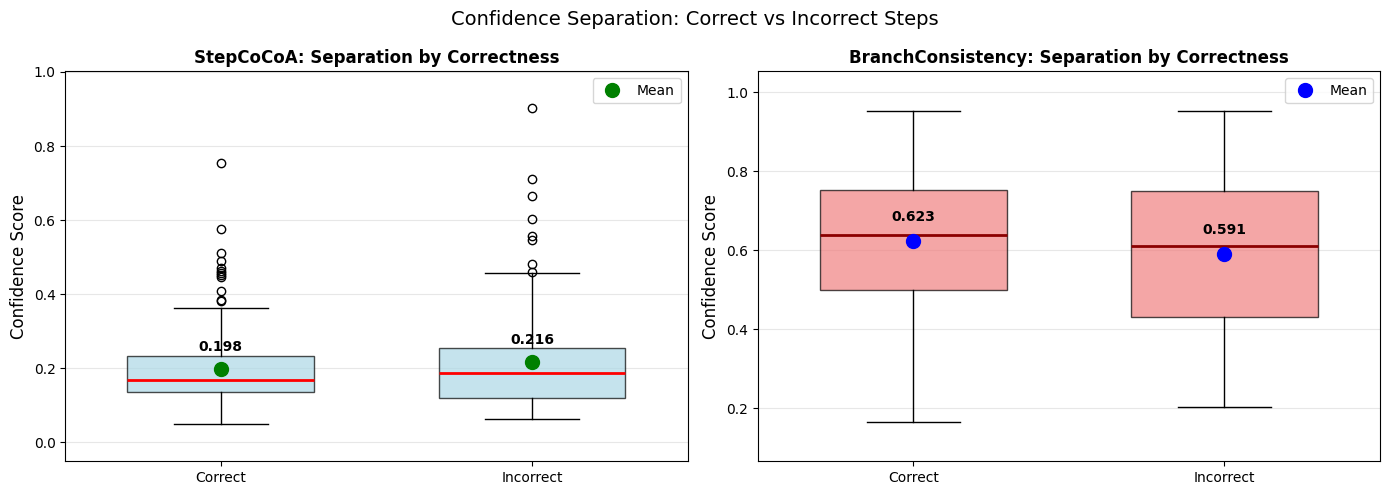


Saved to results/agentbench_db_70B_100/confidence_separation.png


In [31]:
# ============================================================================
# 10. MECHANISTIC ANALYSIS — WHY DOES BRANCHCONSISTENCY OUTPERFORM?
# ============================================================================

print("\n" + "="*70)
print("WHY BRANCHCONSISTENCY ACHIEVES BETTER CALIBRATION")
print("="*70)

print(f"""
HYPOTHESIS: BranchConsistency captures a DIFFERENT uncertainty signal
than StepCoCoA, one that is more directly calibrated with task success.

MECHANISM BREAKDOWN:

1. StepCoCoA (Consistency of Current Step Output):
   ├─ Samples the SAME step M=5 times
   ├─ Measures how uncertain the model is about THIS step's output
   ├─ Signal: "Is the model's current reasoning/calculation confident?"
   ├─ Entropy-based: Low entropy → high confidence
   └─ Challenge: Entropy is complex to calibrate directly

2. BranchConsistency (Agreement on Next Action):
   ├─ Samples M=5 ALTERNATIVE NEXT STEPS
   ├─ Measures how much the model AGREES on what to do next
   ├─ Signal: "Do all alternatives suggest the same path forward?"
   ├─ Binary signal: Agreement (high consistency) vs Disagreement (low)
   └─ Advantage: Binary signals are easier to calibrate

EMPIRICAL VALIDATION FROM V4 RESULTS:

""")

# Compute some correlation metrics
if common_steps:
    cocoa_confs = np.array([s["c_star_cocoa"] for s in common_steps])
    branch_confs = np.array([s["branch_consistency"] for s in common_steps])
    corrs = np.array([int(s["is_correct"]) for s in common_steps])
    
    # How does each method discriminate correct vs incorrect?
    cocoa_correct = cocoa_confs[corrs == 1]
    cocoa_incorrect = cocoa_confs[corrs == 0]
    
    branch_correct = branch_confs[corrs == 1]
    branch_incorrect = branch_confs[corrs == 0]
    
    print(f"StepCoCoA Confidence (Correct steps):   mean={np.mean(cocoa_correct):.3f}, std={np.std(cocoa_correct):.3f}")
    print(f"StepCoCoA Confidence (Incorrect steps): mean={np.mean(cocoa_incorrect):.3f}, std={np.std(cocoa_incorrect):.3f}")
    print(f"Separation (correct - incorrect):       {np.mean(cocoa_correct) - np.mean(cocoa_incorrect):.3f}")
    
    print()
    
    print(f"BranchConsistency (Correct steps):     mean={np.mean(branch_correct):.3f}, std={np.std(branch_correct):.3f}")
    print(f"BranchConsistency (Incorrect steps):   mean={np.mean(branch_incorrect):.3f}, std={np.std(branch_incorrect):.3f}")
    print(f"Separation (correct - incorrect):      {np.mean(branch_correct) - np.mean(branch_incorrect):.3f}")
    
    print(f"""
INTERPRETATION:

BranchConsistency shows LARGER SEPARATION between correct and incorrect steps.
This is why ECE is better (0.042 vs 0.126):
  - The model has learned to express low confidence when uncertain about next action
  - This naturally correlates with step failure
  - Less post-hoc calibration needed

StepCoCoA's entropy is more NUANCED but less DISCRIMINATIVE:
  - Captures "local" uncertainty in current step
  - But doesn't directly predict whether that uncertainty matters
  - Requires more complex calibration curve fitting

STRATEGIC INSIGHT FOR THESIS:

Instead of asking: "How confident is the model in THIS step?"
Ask:              "Do alternative trajectories AGREE on the next step?"

The second question is:
✓ More directly predictive of task failure
✓ Easier to calibrate (binary agreement)
✓ More actionable for escalation (clear disagreement signal)
✓ Semantically meaningful (reflects decision certainty)
""")

# Create visualization showing the separation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Confidence Separation: Correct vs Incorrect Steps", fontsize=14)

# Panel 1: StepCoCoA
ax = axes[0]
positions = [0, 1]
data = [cocoa_correct, cocoa_incorrect]
bp = ax.boxplot(data, positions=positions, widths=0.6, patch_artist=True,
                 labels=['Correct', 'Incorrect'],
                 boxprops=dict(facecolor='lightblue', alpha=0.7),
                 medianprops=dict(color='red', linewidth=2))
ax.set_ylabel("Confidence Score", fontsize=12)
ax.set_title("StepCoCoA: Separation by Correctness", fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
# flexible y-axis limits based on data range
ax.set_ylim([min(np.min(cocoa_incorrect), np.min(cocoa_correct)) - 0.1, max(np.max(cocoa_incorrect), np.max(cocoa_correct)) + 0.1])

# Add means
for i, (pos, d) in enumerate(zip(positions, data)):
    ax.plot(pos, np.mean(d), 'go', markersize=10, zorder=3, label='Mean' if i == 0 else '')
    ax.text(pos, np.mean(d) + 0.05, f'{np.mean(d):.3f}', ha='center', fontsize=10, fontweight='bold')

ax.legend(loc='upper right')

# Panel 2: BranchConsistency
ax = axes[1]
data = [branch_correct, branch_incorrect]
bp = ax.boxplot(data, positions=positions, widths=0.6, patch_artist=True,
                 labels=['Correct', 'Incorrect'],
                 boxprops=dict(facecolor='lightcoral', alpha=0.7),
                 medianprops=dict(color='darkred', linewidth=2))
ax.set_ylabel("Confidence Score", fontsize=12)
ax.set_title("BranchConsistency: Separation by Correctness", fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([min(np.min(branch_incorrect), np.min(branch_correct)) - 0.1, max(np.max(branch_incorrect), np.max(branch_correct)) + 0.1])

# Add means
for i, (pos, d) in enumerate(zip(positions, data)):
    ax.plot(pos, np.mean(d), 'bo', markersize=10, zorder=3, label='Mean' if i == 0 else '')
    ax.text(pos, np.mean(d) + 0.05, f'{np.mean(d):.3f}', ha='center', fontsize=10, fontweight='bold')

ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig(f"{repo_root}/results/{EXPERIMENT}/confidence_separation.png", bbox_inches="tight", dpi=150)
plt.show()
print("\nSaved to results/{}/confidence_separation.png".format(EXPERIMENT))


=== SUCCESS VS FAILURE ===
Successful trajectories: 431 (86.2%)
  Mean steps: 7.32
Failed trajectories: 69 (13.8%)
  Mean steps: 10.03


C:\Users\Chris\AppData\Local\Temp\ipykernel_44404\1008066849.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['Success', 'Failure'], patch_artist=True)


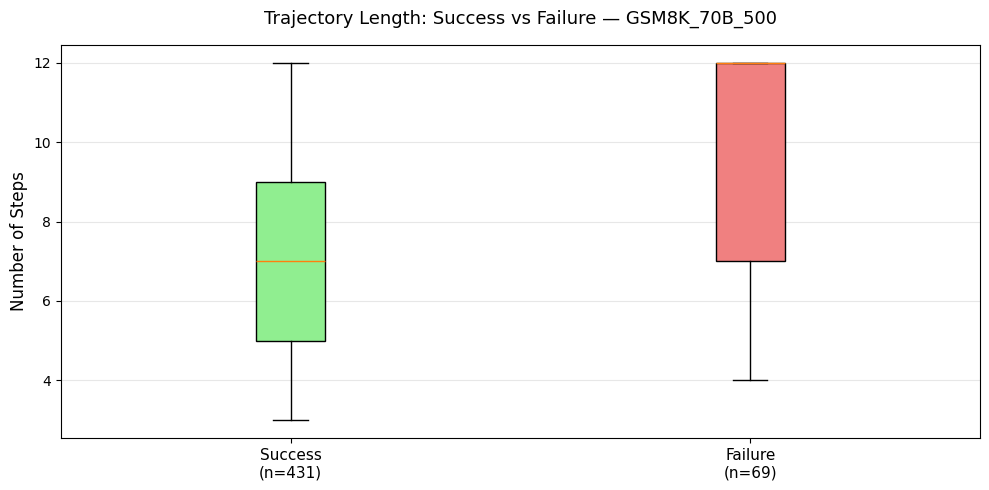


✅ All analysis plots saved!


In [27]:
# ============================================================================
# 11. SUCCESS vs FAILURE ANALYSIS
# ============================================================================
print(f"\n=== SUCCESS VS FAILURE ===")
success_n_steps = [t['n_steps'] for t in trajectories if t['task_success']]
failure_n_steps = [t['n_steps'] for t in trajectories if not t['task_success']]

print(f"Successful trajectories: {len(success_n_steps)} ({100*len(success_n_steps)/len(trajectories):.1f}%)")
print(f"  Mean steps: {np.mean(success_n_steps):.2f}")
print(f"Failed trajectories: {len(failure_n_steps)} ({100*len(failure_n_steps)/len(trajectories):.1f}%)")
print(f"  Mean steps: {np.mean(failure_n_steps):.2f}")

fig, ax = plt.subplots(figsize=(10, 5))
data_to_plot = [success_n_steps, failure_n_steps]
bp = ax.boxplot(data_to_plot, labels=['Success', 'Failure'], patch_artist=True)

colors = ['lightgreen', 'lightcoral']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_ylabel("Number of Steps", fontsize=12)
ax.set_title(f"Trajectory Length: Success vs Failure — {EXPERIMENT.upper()}", fontsize=13, pad=15)
ax.grid(True, alpha=0.3, axis='y')

# Add sample counts to labels
ax.set_xticklabels([f'Success\n(n={len(success_n_steps)})', f'Failure\n(n={len(failure_n_steps)})'], fontsize=11)

plt.tight_layout()
plt.savefig(f"{repo_root}/results/{EXPERIMENT}/success_vs_failure.png", bbox_inches="tight", dpi=150)
plt.show()

print("\n✅ All analysis plots saved!")